Ce fichier enregistre dans un fichier excel les résultats des méthodes AC > 0 avec un fenetre glissante (la durée varie suivant le test effectué) afin de comparer les prédictions obtenues aux prédictions communiquées par mindmaze. Les résultats étant différents, le fichier à été modifié pour affiché les valeurs des annotations selon 3 définition du mouvement : GA (un mouvement correspond uniquement aux annotaions Grande Amplitude volontaire), FAGA (un mouvement correspond aux annotations Grande Amplitude et Faible Amplitude volontaires) et all (un mouvement correspond aux annotations Grande amplitude et Faible Amplitude, volontaires et involontaires).

Pour le lancer et obtenir les données d'un fichier il faut changer 4 paramètres :
- les indices de folder dans la boucle for principale (1. Récupération des AC et des annotations)
- le nom de file_path_dom (4. a. Enregistrement dans excel pour membre dominant)
- le nom de file path_non_dom (4. b. Enregistrement dans excel pour membre non dominant)

Import

In [706]:
import os
import pandas as pd
from agcounts_filter import convert_AC 
import openpyxl
import matplotlib.pyplot as plt 
import numpy as np
from sklearn.metrics import accuracy_score, f1_score
from scipy.signal import butter, filtfilt, resample_poly

Info à compléter

In [707]:
idx_premier_fichier = 0 #52#20
idx_dernier_fichier = 4 #56#24

file_path_non_dom = "C:/Users/roman/Documents/BEaCHILD/Classification/Classification_RCT2/Résultats/2AC_0_et_2AC_2/2AC0_2AC2_dom_04.06.02_MS_02.xlsx"
file_path_dom = "C:/Users/roman/Documents/BEaCHILD/Classification/Classification_RCT2/Résultats/2AC_0_et_2AC_2/2AC0_2AC2_non_dom_04.06.02_MS_02.xlsx"



1. Récupération des AC et des annotations

In [ ]:
folder_path = "C:/Users/roman/Documents/BEaCHILD/Classification/Classification_RCT2/X_et_Y" 
folder = os.listdir(folder_path)

# Initialisation des listes contenant les données des capteurs
X_non_dom = []
X_dom = []
X_th = []

# Initialisation des listes contenant les annotations vidéos
# Annotations all
Y_dom_all = []
Y_non_dom_all = []
# Annotations FAGA
Y_dom_faga = []
Y_non_dom_faga = []
# Annotations GA
Y_dom_ga = []
Y_non_dom_ga = []



#Parcourir les fichiers CSV
for file in folder[idx_premier_fichier:idx_dernier_fichier]:
    print(f"On est dans le fichier : {file}")

    # Extension du fichier
    extension = os.path.splitext(file)[1] 

    # Pour les cas ou il y a des annotations avant le start
    allow_start_dom = None
    allow_start_non_dom = None
    allow_start_th = None

    previous_row_dom = 0
    previous_row_non_dom = 0
    previous_row_th = 0

    """******************************************************** 0. Récupération des infos : idx_file / ID / membre dom / non dom *******************************************************"""
    info_file = pd.read_csv(folder_path + "/Info_file.csv", sep = ',')
    file_row = idx_dernier_fichier / 4 - 1

    subject_id = info_file["subject_id"][file_row]
    dom_member = info_file["dom"][file_row]
    non_dom_member = info_file["non_dom"][file_row]

    """******************************************************** 1. Lecture des fichiers csv et récupération des données capteurs ******************************************************************************"""
    if extension == ".csv":

        # Conversion en AC 
        dom_AC = convert_AC(folder_path + "/" + file)

        # Enregistrement des données des capteurs dans les listes qui seront donnnées au classificateur
        if file[-6:-4] == non_dom_member:
            print("                                                                non_dom : ", non_dom_member)
            list_non_dom_AC = dom_AC["AC"].tolist()
            for ac in list_non_dom_AC :
                X_non_dom.append(ac)

        elif file[-6:-4] == dom_member:
            print("                                                                dom : ", dom_member)
            list_dom_AC = dom_AC["AC"].tolist()
            for ac in list_dom_AC:
                X_dom.append(ac)

        elif file[-6:-4] == "TH":
            list_th_AC = dom_AC["AC"].tolist()
            for ac in list_th_AC:
                X_th.append(ac)


    """********************************************************** 2. Enregistrer les annotations ***************************************************************************"""

    if extension == ".xlsx":

        my_wb = openpyxl.load_workbook(folder_path + "/" + file) 
        my_sheet = my_wb.active

        for label in my_sheet["H"]: 

            """*********************************************** Récupération du début de X ****************************************************"""
            # dom
            # Synchronisation des données X des capteurs et des annotations Y
            if label.value == f"Start_{dom_member}" :
                row_start_dom = label.row
                # Cas ou le capteur dom est allumé en dernier
                if allow_start_non_dom and allow_start_th :
                    # Récuperer le nb de secondes enregistees avant le start général
                    decalage_start_dom = round(float(my_sheet.cell(label.row, 13).value)) - round(float(my_sheet.cell(row_start_dom , 13).value)) #round(float(my_sheet.cell(label.row, 13).value) - float(my_sheet.cell(row_start_dom , 13).value)) 
                    decalage_start_non_dom = round(float(my_sheet.cell(label.row, 13).value)) - round(float(my_sheet.cell(row_start_non_dom , 13).value)) #round(float(my_sheet.cell(label.row, 13).value) - float(my_sheet.cell(row_start_non_dom , 13).value))
                    decalage_start_th = round(float(my_sheet.cell(label.row, 13).value)) - round(float(my_sheet.cell(row_start_th , 13).value)) #round(float(my_sheet.cell(label.row, 13).value) - float(my_sheet.cell(row_start_th , 13).value))
                    # Mise à jour du start général
                    previous_row_th = label.row
                    previous_row_dom = label.row
                    previous_row_non_dom = label.row
                # Pour les cas ou il y a des annotations avant le start 
                allow_start_dom = True

            # non_dom 
            # Synchronisation des données X des capteurs et des annotations Y
            if label.value == f"Start_{non_dom_member}" :
                row_start_non_dom = label.row
                # Cas ou le capteur non_dom est allumé en dernier
                if allow_start_dom and allow_start_th :
                    # Récuperer le nb de secondes enregistees avant le start général
                    decalage_start_dom = round(float(my_sheet.cell(label.row, 13).value)) - round(float(my_sheet.cell(row_start_dom , 13).value)) #round(float(my_sheet.cell(label.row, 13).value) - float(my_sheet.cell(row_start_dom , 13).value)) #
                    decalage_start_non_dom = round(float(my_sheet.cell(label.row, 13).value)) - round(float(my_sheet.cell(row_start_non_dom , 13).value)) #round(float(my_sheet.cell(label.row, 13).value) - float(my_sheet.cell(row_start_non_dom , 13).value)) #round
                    decalage_start_th = round(float(my_sheet.cell(label.row, 13).value)) - round(float(my_sheet.cell(row_start_th , 13).value)) #round(float(my_sheet.cell(label.row, 13).value) - float(my_sheet.cell(row_start_th , 13).value))
                    # Mise à jour du start général
                    previous_row_th = label.row
                    previous_row_dom = label.row
                    previous_row_non_dom = label.row
                # Pour les cas ou il y a des annotations avant le start 
                allow_start_non_dom = True
            
            # thorax
            if label.value == "Start_Thorax" :
                row_start_th = label.row
                # Cas ou le capteur thorax est allumé en dernier
                if allow_start_dom and allow_start_non_dom :
                    # Récuperer le nb de secondes enregistees avant le start général
                    decalage_start_dom = round(float(my_sheet.cell(label.row, 13).value)) - round(float(my_sheet.cell(row_start_dom , 13).value)) #round(float(my_sheet.cell(label.row, 13).value) - float(my_sheet.cell(row_start_dom , 13).value)) #
                    decalage_start_non_dom = round(float(my_sheet.cell(label.row, 13).value)) - round(float(my_sheet.cell(row_start_non_dom , 13).value)) #round(float(my_sheet.cell(label.row, 13).value) - float(my_sheet.cell(row_start_non_dom , 13).value)) #
                    decalage_start_th = round(float(my_sheet.cell(label.row, 13).value)) - round(float(my_sheet.cell(row_start_th , 13).value)) #round(float(my_sheet.cell(label.row, 13).value) - float(my_sheet.cell(row_start_th , 13).value)) #
                    # Mise à jour du start général
                    previous_row_th = label.row
                    previous_row_dom = label.row
                    previous_row_non_dom = label.row
                # Pour les cas ou il y a des annotations avant le start 
                allow_start_th = True

            """****************************************************** Récupération du contenu de Y ****************************************"""

            # Synchroniser X_dom et X_non_dom avec X_th
            if allow_start_dom and allow_start_non_dom and allow_start_th :

                # Récupération des labels dom
                if label.value[0:2] == dom_member:
                    # Récupération de l'index de la ligne
                    row = label.row

                    # *******************************************************************  Secondes non annotées **************************************************
                    # Synchronisation si le start de l'annotation ne correspond pas au stop de l'annotation précédentes
                    if my_sheet.cell(row, 12).value != my_sheet.cell(previous_row_dom, 13).value:
                        difference = round(float(my_sheet.cell(row, 12).value)) - round(float(my_sheet.cell(previous_row_dom , 13).value)) 

                        for diff in range(0, difference):
                            Y_dom_ga.append(None)
                            Y_dom_faga.append(None)
                            Y_dom_all.append(None) 

                    # *******************************************************************  Secondes annotées **************************************************
                    nb_repetitions = int(round(float(my_sheet.cell(label.row, 13).value))) - int(round(float(my_sheet.cell(label.row, 12).value))) 
                    for nb_sec in range(nb_repetitions): 
                        # GA
                        if label.value[-5:] == " V GA":
                            Y_dom_ga.append("mouvement")
                        elif label.value[3:13] == "sédentaire" or label.value[-5:] == "IV GA" or label.value[-2:] == "FA":
                            Y_dom_ga.append("non mouvement")
                        elif label.value[3:12] == "non noté":
                            Y_dom_ga.append(None)

                        # FAGA
                        if label.value[-5:] == " V GA" or label.value[-5:] == " V FA":
                            Y_dom_faga.append("mouvement")
                        elif label.value[3:13] == "sédentaire" or label.value[-5:] == "IV GA" or label.value[-5:] == "IV FA":
                            Y_dom_faga.append("non mouvement")
                        elif label.value[3:12] == "non noté":
                            Y_dom_faga.append(None)

                        # all
                        if label.value[-2:] == "GA" or label.value[-2:] == "FA": 
                            Y_dom_all.append("mouvement")
                        elif label.value[3:13] == "sédentaire": 
                            Y_dom_all.append("non mouvement")
                        elif label.value[3:12] == "non noté":
                            Y_dom_all.append(None)

                    #Au prochain tour, l'indice de la ligne actuelle sera l'index de la ligne précédente
                    previous_row_dom = label.row


                # Récupération des labels non dom
                elif label.value[0:2] == non_dom_member:

                    # Récupération de l'index de la ligne
                    row = label.row

                    # *******************************************************************  Secondes non annotées **************************************************
                    # Synchronisation si le start de l'annotation ne correspond pas au stop de l'annotation précédentes
                    if my_sheet.cell(row, 12).value != my_sheet.cell(previous_row_non_dom, 13).value:
                        #print(my_sheet.cell(row, 12).value)
                        #print(my_sheet.cell(previous_row_non_dom , 13).value)
                        difference = round(float(my_sheet.cell(row, 12).value)) - round(float(my_sheet.cell(previous_row_non_dom , 13).value)) 
                        for diff in range(0,difference):
                            Y_non_dom_ga.append(None)
                            Y_non_dom_faga.append(None)
                            Y_non_dom_all.append(None)
                            

                    #  *******************************************************************  Secondes annotées **************************************************
                    nb_repetitions = int(round(float(my_sheet.cell(label.row, 13).value))) - int(round(float(my_sheet.cell(label.row, 12).value)))
                    for nb_sec in range(nb_repetitions): 

                        # GA 
                        if label.value[-5:] == " V GA":
                            Y_non_dom_ga.append("mouvement")
                        elif label.value[3:13] == "sédentaire" or label.value[-5:] == "IV GA" or label.value[-2:] == "FA":
                            Y_non_dom_ga.append("non mouvement")
                        elif label.value[3:12] == "non noté":
                            Y_non_dom_ga.append(None)
                        # FAGA
                        if label.value[-5:] == " V GA" or label.value[-5:] == " V FA":
                            Y_non_dom_faga.append("mouvement")
                        elif label.value[3:13] == "sédentaire" or label.value[-5:] == "IV GA" or label.value[-5:] == "IV FA":
                            Y_non_dom_faga.append("non mouvement")
                        elif label.value[3:12] == "non noté":
                            Y_non_dom_faga.append(None)

                        # all    
                        if label.value[-2:] == "GA" or label.value[-2:] == "FA":
                            Y_non_dom_all.append("mouvement")
                        elif label.value[3:13] == "sédentaire": 
                            Y_non_dom_all.append("non mouvement")
                        elif label.value[3:12] == "non noté":
                            Y_non_dom_all.append(None)

                    #Au prochain tour, l'indice de la ligne actuelle sera l'index de la ligne précédente
                    previous_row_non_dom = label.row

        print("len Y_dom all ", len(Y_dom_all))
        #print("len Y_non_dom all", len(Y_non_dom_all))
        # Suppression des données des capteurs enregistrées avant le start général (start de synchronisation)
        for sec_a_supp_dom in range(decalage_start_dom):
            X_dom.pop(0)
        for sec_a_supp_non_dom in range(decalage_start_non_dom):
            X_non_dom.pop(0)
        for sec_a_supp_th in range(decalage_start_th):
            X_th.pop(0)

        # Découpage de toutes les listes à la même longueur
        min_longueur = min(len(X_dom), len(X_non_dom), len(X_th), len(Y_dom_all), len(Y_non_dom_all)) # 
        X_dom = X_dom[:min_longueur]
        X_non_dom = X_non_dom[:min_longueur]
        X_th = X_th[:min_longueur]
        Y_dom_all = Y_dom_all[:min_longueur]
        Y_non_dom_all = Y_non_dom_all[:min_longueur]
        Y_dom_faga = Y_dom_faga[:min_longueur]
        Y_non_dom_faga = Y_non_dom_faga[:min_longueur]
        Y_dom_ga = Y_dom_ga[:min_longueur]
        Y_non_dom_ga = Y_non_dom_ga[:min_longueur]

print(len(Y_dom_all))
print(len(X_dom))
Y_dom_all = np.array(Y_dom_all)
Y_non_dom_all = np.array(Y_non_dom_all)
X_dom = np.array(X_dom)
X_non_dom = np.array(X_non_dom)



On est dans le fichier : Data_231_LW.csv
Reading in CSV
Converting to array
Getting Counts
                                                                dom :  LW
On est dans le fichier : Data_231_RW.csv
Reading in CSV
Converting to array
Getting Counts
                                                                non_dom :  RW
On est dans le fichier : Data_231_TH.csv
Reading in CSV
Converting to array
Getting Counts
On est dans le fichier : Data_231_X.xlsx
len Y_dom all  916
916
916


In [709]:

print(len(X_dom))
print(len(X_non_dom))
print(len(X_th))
print(len(Y_dom_all))
print(len(Y_non_dom_all))
print("decalage dom ", decalage_start_dom)
print("decalage non dom ", decalage_start_non_dom)
print("decalage thorax ", decalage_start_th)

916
916
916
916
916
decalage dom  0
decalage non dom  15
decalage thorax  15


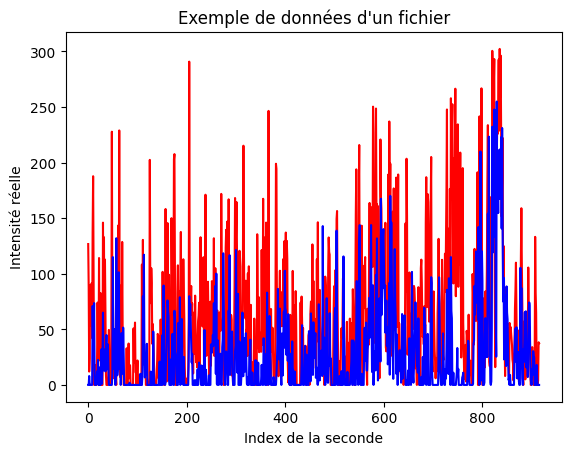

In [710]:
plt.plot(range(len(X_dom)), X_dom, color = 'red')# points : plt.scatter
plt.plot(range(len(X_dom)), X_non_dom, color = 'blue')
#plt.plot(range(len(X_dom)), X_th, color = 'green')
plt.title("Exemple de données d'un fichier")
plt.xlabel("Index de la seconde")
plt.ylabel("Intensité réelle")
plt.show()

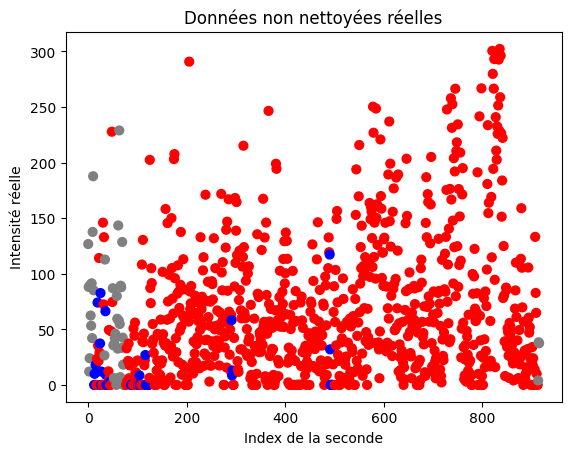

In [711]:
# Crée un mapping de couleur pour chaque label
label_to_color = {'mouvement': 'red', 'non mouvement': 'blue', None : 'grey'}
colors = [label_to_color[y] for y in Y_dom_all]
# Affichage : index en abscisse, intensité en ordonnée
plt.scatter(range(len(X_dom[:len(Y_dom_all)])), X_dom, c=colors, s=40)
plt.title("Données non nettoyées réelles")
plt.xlabel("Index de la seconde")
plt.ylabel("Intensité réelle")
plt.show()

2. Calcul X_dom et X_non_dom par rapport à X_th

3. Seuil 2AC > 0 et 2AC > 2

In [712]:
lst_X_members = [X_dom, X_non_dom]

lst_Y_pred = []
lst_Y_pred_2s = []

for idx_members in range(2):
    # On a X_dom et Y_dom : construire un Y_pred et le comparer à Y_dom
    Y_pred_0 = []
    Y_pred_2 = []
    for idx_data in range(0,len(lst_X_members[idx_members])-2,2): 
        seuil = lst_X_members[idx_members][idx_data] + lst_X_members[idx_members][idx_data + 1] 
        if seuil> 0:
            Y_pred_0.append(1)
            Y_pred_0.append(1)
        elif seuil <= 0 : 
            Y_pred_0.append(0)
            Y_pred_0.append(0)
        else:
            Y_pred_0.append(None)
            Y_pred_0.append(None)

    
    # Seuillage : mouvement si 2AC > 2
    for idx_data in range(0,len(lst_X_members[idx_members])-1, 2):
        seuil = lst_X_members[idx_members][idx_data] + lst_X_members[idx_members][idx_data + 1]
        if seuil  > 2: 
            Y_pred_2.append(1)
            Y_pred_2.append(1)
        elif seuil  <= 2 :
            Y_pred_2.append(0)
            Y_pred_2.append(0)
        else:
            Y_pred_2.append(None)
            Y_pred_2.append(None)
    
        
    lst_Y_pred.append(Y_pred_0)
    lst_Y_pred_2s.append(Y_pred_2)


4. a. Nettoyage des AC et de leurs annotations

In [713]:
total_list_dom_sec = np.arange(1,len(Y_dom_all)+1)
total_list_non_dom_sec = np.arange(1,len(Y_non_dom_all)+1)
lst_Y_pred[0] = np.array(lst_Y_pred[0])
lst_Y_pred[1] = np.array(lst_Y_pred[1])
lst_Y_pred_2s[0] = np.array(lst_Y_pred_2s[0])
lst_Y_pred_2s[1] = np.array(lst_Y_pred_2s[1])

# Créer un masque pour garder uniquement les étiquettes valides (différent de None)
mask_dom = Y_dom_all != None
# Créer un masque pour garder uniquement les étiquettes valides (différent de None)
mask_non_dom = Y_non_dom_all != None

print("len mask non dom : ", len(mask_dom))
print("len lst_Y_pred_O : ", len(lst_Y_pred[0]))
lst_Y_pred[0] = lst_Y_pred[0][mask_dom[:len(lst_Y_pred[0])]]
lst_Y_pred[1] = lst_Y_pred[1][mask_non_dom[:len(lst_Y_pred[1])]]
lst_Y_pred_2s[0] = lst_Y_pred_2s[0][mask_dom[:len(lst_Y_pred_2s[0])]]
lst_Y_pred_2s[1] = lst_Y_pred_2s[1][mask_non_dom[:len(lst_Y_pred_2s[1])]]

Y_dom_all = Y_dom_all[mask_dom]
Y_non_dom_all = Y_non_dom_all[mask_non_dom]
X_dom = X_dom[mask_dom]
X_non_dom = X_non_dom[mask_non_dom]
list_dom_sec =  total_list_dom_sec[mask_dom]
list_non_dom_sec = total_list_non_dom_sec[mask_non_dom]

print("len(Y_non_dom) après nettoyage :", len(Y_non_dom_all))

len mask non dom :  916
len lst_Y_pred_O :  914
len(Y_non_dom) après nettoyage : 875


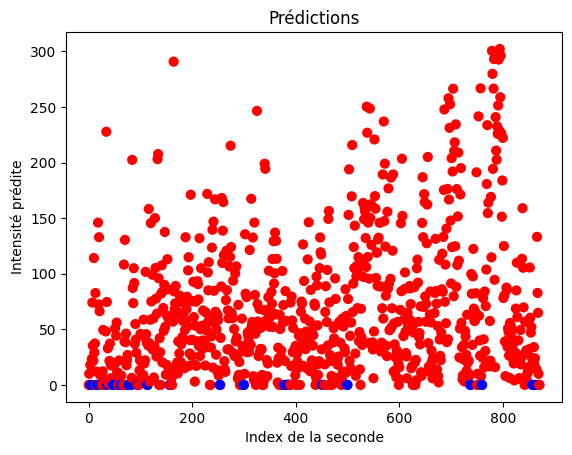

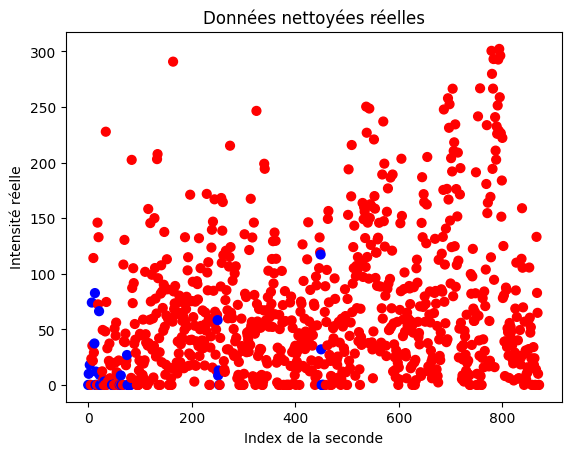

In [714]:
# Crée un mapping de couleur pour chaque label
label_to_color = {0: 'blue', 1: 'red', None : 'grey'}
colors = [label_to_color[y] for y in lst_Y_pred[0]]
# Affichage : index en abscisse, intensité en ordonnée
plt.scatter(range(len(X_dom[:len(lst_Y_pred[0])])), X_dom[:len(lst_Y_pred[0])], c=colors, s=40)#X_dom[:len(lst_Y_pred[0])])
plt.title("Prédictions")
plt.xlabel("Index de la seconde")
plt.ylabel("Intensité prédite")
plt.show()

# Crée un mapping de couleur pour chaque label
label_to_color = {'non mouvement': 'blue','mouvement': 'red',  None : 'grey'}
colors = [label_to_color[y] for y in Y_dom_all]
# Affichage : index en abscisse, intensité en ordonnée
plt.scatter(range(len(X_dom[:len(Y_dom_all)])), X_dom[:len(Y_dom_all)], c=colors, s=40)#len(X_dom[:len(Y_dom[2000:2500])]
plt.title("Données nettoyées réelles")
plt.xlabel("Index de la seconde")
plt.ylabel("Intensité réelle")
plt.show()


4. b. Nettoyage des annotations faga et ga

In [715]:
Y_dom_faga = np.array(Y_dom_faga)
Y_non_dom_faga = np.array(Y_non_dom_faga)
Y_dom_ga = np.array(Y_dom_ga)
Y_non_dom_ga = np.array(Y_non_dom_ga)


# GA
# Créer un masque pour garder uniquement les étiquettes valides (différent de None)
mask_ga_dom = Y_dom_ga != None
# Créer un masque pour garder uniquement les étiquettes valides (différent de None)
mask_ga_non_dom = Y_non_dom_ga != None

Y_dom_ga = Y_dom_ga[mask_ga_dom]
Y_non_dom_ga = Y_non_dom_ga[mask_ga_non_dom]

#FAGA
# Créer un masque pour garder uniquement les étiquettes valides (différent de None)
mask_faga_dom = Y_dom_faga != None
# Créer un masque pour garder uniquement les étiquettes valides (différent de None)
mask_faga_non_dom = Y_non_dom_faga != None

Y_dom_faga = Y_dom_faga[mask_faga_dom]
Y_non_dom_faga = Y_non_dom_faga[mask_faga_non_dom]


In [716]:
print("Len dom : ", len(Y_dom_all))
print("Len non dom : ", len(Y_non_dom_all))

Len dom :  872
Len non dom :  875


5. Accuracy et F1 scores

In [717]:
Y_dom_all = np.array(Y_dom_all)
Y_non_dom_all = np.array(Y_non_dom_all)
Y_dom_faga = np.array(Y_dom_faga)
Y_non_dom_faga = np.array(Y_non_dom_faga)
Y_dom_ga = np.array(Y_dom_ga)
Y_non_dom_ga = np.array(Y_non_dom_ga)

# -------------------------------------------- Transformation des labels --------------------------------------------
# Transformation des labels GA
Y_dom_ga_int = np.where(Y_dom_ga == 'mouvement' , 1, 0)
Y_non_dom_ga_int = np.where(Y_non_dom_ga == "mouvement", 1, 0)

# Transformation des labels GA
Y_dom_faga_int = np.where(Y_dom_faga == "mouvement" , 1, 0)
Y_non_dom_faga_int = np.where(Y_non_dom_faga == "mouvement", 1, 0)

# Transformation des labels all
Y_dom_all_int = np.where(Y_dom_all == "mouvement" , 1, 0)
Y_non_dom_all_int = np.where(Y_non_dom_all == "mouvement", 1, 0)

# ---------------------------- lst_Y_pred sont des numpy int mais Y_dom_all sont des int : il faut convertir les numpy int pour qu'ils correspondent aux int ------------------------------
# ga
Y_dom_ga_int = np.array(Y_dom_ga_int, dtype=np.int32)
Y_non_dom_ga_int = np.array(Y_non_dom_ga_int, dtype=np.int32)

# all
Y_dom_faga_int = np.array(Y_dom_faga_int, dtype=np.int32)
Y_non_dom_faga_int = np.array(Y_non_dom_faga_int, dtype=np.int32)

# all
Y_dom_all_int = np.array(Y_dom_all_int, dtype=np.int32)
Y_non_dom_all_int = np.array(Y_non_dom_all_int, dtype=np.int32)

# -------------------------------------------- Accuracy ---------------------------------------------

# ga
accuracy_dom_ga_0 = accuracy_score(Y_dom_ga_int[:len(lst_Y_pred[0])],lst_Y_pred[0])
#print("Accuracy dom ga : ", accuracy_dom_ga_0)
accuracy_non_dom_ga_0 = accuracy_score(Y_non_dom_ga_int[:len(lst_Y_pred[1])],lst_Y_pred[1])
#print("Accuracy non dom ga : ", accuracy_non_dom_ga_0)
accuracy_dom_ga_2s = accuracy_score(Y_dom_ga_int[:len(lst_Y_pred_2s[0])],lst_Y_pred_2s[0])
#print("Accuracy dom ga : ", accuracy_dom_ga_2s)
accuracy_non_dom_ga_2s = accuracy_score(Y_non_dom_ga_int[:len(lst_Y_pred_2s[1])],lst_Y_pred_2s[1])
#print("Accuracy non dom ga : ", accuracy_non_dom_ga_2s)

# faga
accuracy_dom_faga_0 = accuracy_score(Y_dom_faga_int[:len(lst_Y_pred[0])],lst_Y_pred[0])
#print("Accuracy dom faga : ", accuracy_dom_faga_0)
accuracy_non_dom_faga_0 = accuracy_score(Y_non_dom_faga_int[:len(lst_Y_pred[1])],lst_Y_pred[1])
#print("Accuracy non dom faga : ", accuracy_non_dom_faga_0)
accuracy_dom_faga_2s = accuracy_score(Y_dom_faga_int[:len(lst_Y_pred_2s[0])],lst_Y_pred_2s[0])
#print("Accuracy dom faga : ", accuracy_dom_faga_2s)
accuracy_non_dom_faga_2s = accuracy_score(Y_non_dom_faga_int[:len(lst_Y_pred_2s[1])],lst_Y_pred_2s[1])
#print("Accuracy non dom faga : ", accuracy_non_dom_faga_2s)

# all
accuracy_dom_all_0 = accuracy_score(Y_dom_all_int[:len(lst_Y_pred[0])],lst_Y_pred[0])
print("Accuracy dom all : ", accuracy_dom_all_0)
accuracy_non_dom_all_0 = accuracy_score(Y_non_dom_all_int[:len(lst_Y_pred[1])],lst_Y_pred[1])
print("Accuracy non dom all : ", accuracy_non_dom_all_0)
accuracy_dom_all_2s = accuracy_score(Y_dom_all_int[:len(lst_Y_pred_2s[0])],lst_Y_pred_2s[0])
print("Accuracy dom all : ", accuracy_dom_all_2s)
accuracy_non_dom_all_2s = accuracy_score(Y_non_dom_all_int[:len(lst_Y_pred_2s[1])],lst_Y_pred_2s[1])
print("Accuracy non dom all : ", accuracy_non_dom_all_2s)


# -------------------------------------------- F1 scores  ---------------------------------------------
# ga 
# 2AC > 0
f1_mvt_dom_ga_0 = f1_score(Y_dom_ga_int[:len(lst_Y_pred[0])],lst_Y_pred[0], labels = [0,1], pos_label = 1 , average = "binary")
f1_non_mvt_dom_ga_0 = f1_score(Y_dom_ga_int[:len(lst_Y_pred[0])],lst_Y_pred[0], labels = [0,1], pos_label = 0 , average = "binary")
f1_mvt_non_dom_ga_0 = f1_score(Y_non_dom_ga_int[:len(lst_Y_pred[1])],lst_Y_pred[1], labels = [0,1], pos_label = 1 , average = "binary")
f1_non_mvt_non_dom_ga_0 = f1_score(Y_non_dom_ga_int[:len(lst_Y_pred[1])],lst_Y_pred[1], labels = [0,1], pos_label = 0 , average = "binary")
# 2AC > 2
f1_mvt_dom_ga_2s = f1_score(Y_dom_ga_int[:len(lst_Y_pred_2s[0])],lst_Y_pred_2s[0], labels = [0,1], pos_label = 1 , average = "binary")
f1_non_mvt_dom_ga_2s = f1_score(Y_dom_ga_int[:len(lst_Y_pred_2s[0])],lst_Y_pred_2s[0], labels = [0,1], pos_label = 0 , average = "binary")
f1_mvt_non_dom_ga_2s = f1_score(Y_non_dom_ga_int[:len(lst_Y_pred_2s[1])],lst_Y_pred_2s[1], labels = [0,1], pos_label = 1 , average = "binary")
f1_non_mvt_non_dom_ga_2s = f1_score(Y_non_dom_ga_int[:len(lst_Y_pred_2s[1])],lst_Y_pred_2s[1], labels = [0,1], pos_label = 0 , average = "binary")

# faga
# 2AC > 0
f1_mvt_dom_faga_0 = f1_score(Y_dom_faga_int[:len(lst_Y_pred[0])],lst_Y_pred[0], labels = [0,1], pos_label = 1 , average = "binary")
f1_non_mvt_dom_faga_0 = f1_score(Y_dom_faga_int[:len(lst_Y_pred[0])],lst_Y_pred[0], labels = [0,1], pos_label = 0 , average = "binary")
f1_mvt_non_dom_faga_0 = f1_score(Y_non_dom_faga_int[:len(lst_Y_pred[1])],lst_Y_pred[1], labels = [0,1], pos_label = 1 , average = "binary")
f1_non_mvt_non_dom_faga_0 = f1_score(Y_non_dom_faga_int[:len(lst_Y_pred[1])],lst_Y_pred[1], labels = [0,1], pos_label = 0 , average = "binary")
# 2AC > 2
f1_mvt_dom_faga_2s = f1_score(Y_dom_faga_int[:len(lst_Y_pred_2s[0])],lst_Y_pred_2s[0], labels = [0,1], pos_label = 1 , average = "binary")
f1_non_mvt_dom_faga_2s = f1_score(Y_dom_faga_int[:len(lst_Y_pred_2s[0])],lst_Y_pred_2s[0], labels = [0,1], pos_label = 0 , average = "binary")
f1_mvt_non_dom_faga_2s = f1_score(Y_non_dom_faga_int[:len(lst_Y_pred_2s[1])],lst_Y_pred_2s[1], labels = [0,1], pos_label = 1 , average = "binary")
f1_non_mvt_non_dom_faga_2s = f1_score(Y_non_dom_faga_int[:len(lst_Y_pred_2s[1])],lst_Y_pred_2s[1], labels = [0,1], pos_label = 0 , average = "binary")

# all
# 2AC > 0
f1_mvt_dom_all_0 = f1_score(Y_dom_all_int[:len(lst_Y_pred[0])],lst_Y_pred[0], labels = [0,1], pos_label = 1 , average = "binary")
f1_non_mvt_dom_all_0 = f1_score(Y_dom_all_int[:len(lst_Y_pred[0])],lst_Y_pred[0], labels = [0,1], pos_label = 0 , average = "binary")
f1_mvt_non_dom_all_0 = f1_score(Y_non_dom_all_int[:len(lst_Y_pred[1])],lst_Y_pred[1], labels = [0,1], pos_label = 1 , average = "binary")
f1_non_mvt_non_dom_all_0 = f1_score(Y_non_dom_all_int[:len(lst_Y_pred[1])],lst_Y_pred[1], labels = [0,1], pos_label = 0 , average = "binary")
# 2AC > 2
f1_mvt_dom_all_2s = f1_score(Y_dom_all_int[:len(lst_Y_pred_2s[0])],lst_Y_pred_2s[0], labels = [0,1], pos_label = 1 , average = "binary")
f1_non_mvt_dom_all_2s = f1_score(Y_dom_all_int[:len(lst_Y_pred_2s[0])],lst_Y_pred_2s[0], labels = [0,1], pos_label = 0 , average = "binary")
f1_mvt_non_dom_all_2s = f1_score(Y_non_dom_all_int[:len(lst_Y_pred_2s[1])],lst_Y_pred_2s[1], labels = [0,1], pos_label = 1 , average = "binary")
f1_non_mvt_non_dom_all_2s = f1_score(Y_non_dom_all_int[:len(lst_Y_pred_2s[1])],lst_Y_pred_2s[1], labels = [0,1], pos_label = 0 , average = "binary")




Accuracy dom all :  0.9346330275229358
Accuracy non dom all :  0.72
Accuracy dom all :  0.9323394495412844
Accuracy non dom all :  0.7085714285714285


6. Enregistrement dans Excel

a. Membre dominant

In [718]:
# Select file
if os.path.exists(file_path_dom):
    my_wb = openpyxl.load_workbook(file_path_dom)  
    print("File exists, loading existing data.")
else:
    # Create file 
    my_wb = openpyxl.Workbook()
    print("File does not exist, creating a new file.")

# Nomenclature des colonnes
my_sheet = my_wb.active



names_column = ["Timecode (sec)", "AC > 2 avec fenetre de 10s (0 no movement, 1 movement)", "AC > 2 (0 no movement, 1 movement)", "GA observation (0 no movement, 1 movement)", "GAFA Observation (0 no movement, 1 movement)", "all observation (0 no movement, 1 movement)"]
for name_nb in range(0,len(names_column)) :
    print("créer une colonne")
    my_cell = my_sheet.cell(row = 1, column = name_nb + 1)
    my_cell.value = names_column[name_nb]


# 1ere colonne = seconde
for idx_sec in range(len(list_dom_sec)):
    my_cell = my_sheet.cell(row = idx_sec + 2, column = 1)
    my_cell.value = list_dom_sec[idx_sec]

# 2e colonne = 10AC > 0 
for idx_pred_10s in range(len(lst_Y_pred_2s[0])):
    my_cell = my_sheet.cell(row = idx_pred_10s + 2, column = 2)
    my_cell.value = lst_Y_pred_2s[0][idx_pred_10s]

# 3e colonne = résultats AC > 0
for idx_pred_AC in range(len(lst_Y_pred[0])):
    my_cell = my_sheet.cell(row = idx_pred_AC + 2, column = 3)
    my_cell.value = int(lst_Y_pred[0][idx_pred_AC])

# 4e colonne = Observation GA
for idx_obs_ga in range(len(Y_dom_ga)):
    my_cell = my_sheet.cell(row = idx_obs_ga + 2, column = 4)
    if Y_dom_ga[idx_obs_ga] == "mouvement":
        my_cell.value = 1
    elif Y_dom_ga[idx_obs_ga] == "non mouvement":
        my_cell.value = 0
    else:
        my_cell.value = None

# 5e colonne = Observation GAFA
for idx_obs_gafa in range(len(Y_dom_faga)):
    my_cell = my_sheet.cell(row = idx_obs_gafa + 2, column = 5)
    if Y_dom_faga[idx_obs_gafa] == "mouvement":
        my_cell.value = 1
    elif Y_dom_faga[idx_obs_gafa] == "non mouvement":
        my_cell.value = 0
    else:
        #print(Y_dom_faga[idx_obs_gafa])
        my_cell.value = "ERREUR"

# 6e colonne = Observation All
for idx_obs_all in range(len(Y_dom_all)):
    my_cell = my_sheet.cell(row = idx_obs_all + 2, column = 6)
    if Y_dom_all[idx_obs_all] == "mouvement":
        my_cell.value = 1
    elif Y_dom_all[idx_obs_all] == "non mouvement":
        my_cell.value = 0
    else:
        #print(Y_dom_all[idx_obs_all])
        my_cell.value = "ERREUR"

# Autres colonnes : accuracy et F1 scores modèle 1
my_cell_title = my_sheet.cell(row = 5, column = 11)
my_cell_title.value = "2AC > 0"
my_cell_title_acc_fa = my_sheet.cell(row = 6, column = 11)
my_cell_title_acc_fa.value = "Accuracy ga 2AC > 0"
my_cell_title_acc_gafa = my_sheet.cell(row = 6, column = 12)
my_cell_title_acc_gafa.value = "Accuracy faga 2AC > 0"
my_cell_title_acc_all = my_sheet.cell(row = 6, column = 13)
my_cell_title_acc_all.value = "Accuracy all 2AC > 0"

my_cell_acc_ga = my_sheet.cell(row = 7, column = 11)
my_cell_acc_ga.value = accuracy_dom_ga_0
my_cell_acc_faga = my_sheet.cell(row = 7, column = 12)
my_cell_acc_faga.value = accuracy_dom_faga_0
my_cell_acc_all = my_sheet.cell(row = 7, column = 13)
my_cell_acc_all.value = accuracy_dom_all_0

my_cell_title_F1_mvt = my_sheet.cell(row = 8, column = 11)
my_cell_title_F1_mvt.value = "F1 mvt "
my_cell_title_F1_mvt_fa = my_sheet.cell(row = 9, column = 11)
my_cell_title_F1_mvt_fa.value = "F1 mvt ga 2AC > 0"
my_cell_title_F1_mvt_gafa = my_sheet.cell(row =9, column = 12)
my_cell_title_F1_mvt_gafa.value = "F1 mvt faga 2AC > 0"
my_cell_title_F1_mvt_all = my_sheet.cell(row = 9, column = 13)
my_cell_title_F1_mvt_all.value = "F1 mvt all 2AC > 0"

my_cell_F1_mvt_ga = my_sheet.cell(row = 10, column = 11)
my_cell_F1_mvt_ga.value = f1_mvt_dom_ga_0
my_cell_F1_mvt_faga = my_sheet.cell(row = 10, column = 12)
my_cell_F1_mvt_faga.value = f1_mvt_dom_faga_0
my_cell_F1_mvt_all = my_sheet.cell(row = 10, column = 13)
my_cell_F1_mvt_all.value = f1_mvt_dom_all_0

my_cell_title_F1_mvt = my_sheet.cell(row = 11, column = 11)
my_cell_title_F1_mvt.value = "F1 non mvt "
my_cell_title_F1_non_mvt_fa = my_sheet.cell(row = 12, column = 11)
my_cell_title_F1_non_mvt_fa.value = "F1 non mvt ga 2AC > 0"
my_cell_title_F1_non_mvt_gafa = my_sheet.cell(row = 12, column = 12)
my_cell_title_F1_non_mvt_gafa.value = "F1 non mvt faga 2AC > 0"
my_cell_title_F1_non_mvt_all = my_sheet.cell(row = 12, column = 13)
my_cell_title_F1_non_mvt_all.value = "F1 non mvt all 2AC > 0"

my_cell_F1_non_mvt_ga = my_sheet.cell(row = 13, column = 11)
my_cell_F1_non_mvt_ga.value = f1_non_mvt_dom_ga_0
my_cell_F1_non_mvt_faga = my_sheet.cell(row = 13, column = 12)
my_cell_F1_non_mvt_faga.value = f1_non_mvt_dom_faga_0
my_cell_F1_non_mvt_all = my_sheet.cell(row = 13, column = 13)
my_cell_F1_non_mvt_all.value = f1_non_mvt_dom_all_0

# Autres colonnes : accuracy et F1 scores modèle 2
my_cell_title = my_sheet.cell(row = 5, column = 15)
my_cell_title.value = "2AC > 2"
my_cell_title_acc_fa = my_sheet.cell(row = 6, column = 15)
my_cell_title_acc_fa.value = "Accuracy ga 2AC > 2"
my_cell_title_acc_gafa = my_sheet.cell(row = 6, column = 16)
my_cell_title_acc_gafa.value = "Accuracy faga 2AC > 2"
my_cell_title_acc_all = my_sheet.cell(row = 6, column = 17)
my_cell_title_acc_all.value = "Accuracy all 2AC > 2"

my_cell_acc_ga = my_sheet.cell(row = 7, column = 15)
my_cell_acc_ga.value = accuracy_dom_ga_2s
my_cell_acc_faga = my_sheet.cell(row = 7, column = 16)
my_cell_acc_faga.value = accuracy_dom_faga_2s
my_cell_acc_all = my_sheet.cell(row = 7, column = 17)
my_cell_acc_all.value = accuracy_dom_all_2s

my_cell_title_F1_mvt = my_sheet.cell(row = 8, column = 15)
my_cell_title_F1_mvt.value = "F1 mvt "
my_cell_title_F1_mvt_fa = my_sheet.cell(row = 9, column = 15)
my_cell_title_F1_mvt_fa.value = "F1 mvt ga 2AC > 2"
my_cell_title_F1_mvt_gafa = my_sheet.cell(row =9, column = 16)
my_cell_title_F1_mvt_gafa.value = "F1 mvt faga 2AC > 2"
my_cell_title_F1_mvt_all = my_sheet.cell(row = 9, column = 17)
my_cell_title_F1_mvt_all.value = "F1 mvt all 2AC > 2"

my_cell_F1_mvt_ga = my_sheet.cell(row = 10, column = 15)
my_cell_F1_mvt_ga.value = f1_mvt_dom_ga_2s
my_cell_F1_mvt_faga = my_sheet.cell(row = 10, column = 16)
my_cell_F1_mvt_faga.value = f1_mvt_dom_faga_2s
my_cell_F1_mvt_all = my_sheet.cell(row = 10, column = 17)
my_cell_F1_mvt_all.value = f1_mvt_dom_all_2s

my_cell_title_F1_mvt = my_sheet.cell(row = 11, column = 15)
my_cell_title_F1_mvt.value = "F1 non mvt "
my_cell_title_F1_non_mvt_fa = my_sheet.cell(row = 12, column = 15)
my_cell_title_F1_non_mvt_fa.value = "F1 non mvt ga 2AC > 2"
my_cell_title_F1_non_mvt_gafa = my_sheet.cell(row = 12, column = 16)
my_cell_title_F1_non_mvt_gafa.value = "F1 non mvt faga 2AC > 2"
my_cell_title_F1_non_mvt_all = my_sheet.cell(row = 12, column = 17)
my_cell_title_F1_non_mvt_all.value = "F1 non mvt all 2AC > 2"

my_cell_F1_non_mvt_ga = my_sheet.cell(row = 13, column = 15)
my_cell_F1_non_mvt_ga.value = f1_non_mvt_dom_ga_2s
my_cell_F1_non_mvt_faga = my_sheet.cell(row = 13, column = 16)
my_cell_F1_non_mvt_faga.value = f1_non_mvt_dom_faga_2s
my_cell_F1_non_mvt_all = my_sheet.cell(row = 13, column = 17)
my_cell_F1_non_mvt_all.value = f1_non_mvt_dom_all_2s

my_cell_time = my_sheet.cell(row = 7, column = 9)
my_cell_time.value = "Temps annoté "
my_cell_time_value = my_sheet.cell(row = 8, column = 9)
my_cell_time_value.value = len(Y_dom_all)

my_wb.save(file_path_dom)


File does not exist, creating a new file.
créer une colonne
créer une colonne
créer une colonne
créer une colonne
créer une colonne
créer une colonne


b. Membre non dominant

In [719]:
# Select file
if os.path.exists(file_path_non_dom):
    my_wb = openpyxl.load_workbook(file_path_non_dom)  
    print("File exists, loading existing data.")
else:
    # Create file 
    my_wb = openpyxl.Workbook()
    print("File does not exist, creating a new file.")

# Nomenclature des colonnes
my_sheet = my_wb.active



names_column = ["Timecode (sec)", "AC > 2 avec fenetre de 10s (0 no movement, 1 movement)", "AC > 2 (0 no movement, 1 movement)", "GA observation (0 no movement, 1 movement)", "GAFA Observation (0 no movement, 1 movement)", "all observation (0 no movement, 1 movement)"]
for name_nb in range(0,len(names_column)) :
    print("créer une colonne")
    my_cell = my_sheet.cell(row = 1, column = name_nb + 1)
    my_cell.value = names_column[name_nb]


# 1ere colonne = seconde
for idx_sec in range(len(list_non_dom_sec)):
    my_cell = my_sheet.cell(row = idx_sec + 2, column = 1)
    my_cell.value = list_non_dom_sec[idx_sec]

# 2e colonne = résultats Coley
for idx_pred_10s in range(len(lst_Y_pred_2s[1])):
    my_cell = my_sheet.cell(row = idx_pred_10s + 2, column = 2)
    my_cell.value = lst_Y_pred_2s[1][idx_pred_10s]

# 3e colonne = résultats AC > 2
for idx_pred_AC in range(len(lst_Y_pred[1])):
    my_cell = my_sheet.cell(row = idx_pred_AC + 2, column = 3)
    my_cell.value = int(lst_Y_pred[1][idx_pred_AC])

# 4e colonne = Observation GA
for idx_obs_ga in range(len(Y_non_dom_ga)):
    my_cell = my_sheet.cell(row = idx_obs_ga + 2, column = 4)
    if Y_non_dom_ga[idx_obs_ga] == "mouvement":
        my_cell.value = 1
    elif Y_non_dom_ga[idx_obs_ga] == "non mouvement":
        my_cell.value = 0
    else:
        my_cell.value = None

# 5e colonne = Observation GAFA
for idx_obs_gafa in range(len(Y_non_dom_faga)):
    my_cell = my_sheet.cell(row = idx_obs_gafa + 2, column = 5)
    if Y_non_dom_faga[idx_obs_gafa] == "mouvement":
        my_cell.value = 1
    elif Y_non_dom_faga[idx_obs_gafa] == "non mouvement":
        my_cell.value = 0
    else:
        #print(Y_non_dom_faga[idx_obs_gafa])
        my_cell.value = "ERREUR"

# 6e colonne = Observation All
for idx_obs_all in range(len(Y_non_dom_all)):
    my_cell = my_sheet.cell(row = idx_obs_all + 2, column = 6)
    if Y_non_dom_all[idx_obs_all] == "mouvement":
        my_cell.value = 1
    elif Y_non_dom_all[idx_obs_all] == "non mouvement":
        my_cell.value = 0
    else:
        #print(Y_non_dom_all[idx_obs_all])
        my_cell.value = "ERREUR"

        
# Autres colonnes : accuracy et F1 scores modèle 1
my_cell_title = my_sheet.cell(row = 5, column = 11)
my_cell_title.value = "2AC > 0"
my_cell_title_acc_fa = my_sheet.cell(row = 6, column = 11)
my_cell_title_acc_fa.value = "Accuracy ga"
my_cell_title_acc_gafa = my_sheet.cell(row = 6, column = 12)
my_cell_title_acc_gafa.value = "Accuracy faga"
my_cell_title_acc_all = my_sheet.cell(row = 6, column = 13)
my_cell_title_acc_all.value = "Accuracy all"

my_cell_acc_ga = my_sheet.cell(row = 7, column = 11)
my_cell_acc_ga.value = accuracy_non_dom_ga_0
my_cell_acc_faga = my_sheet.cell(row = 7, column = 12)
my_cell_acc_faga.value = accuracy_non_dom_faga_0
my_cell_acc_all = my_sheet.cell(row = 7, column = 13)
my_cell_acc_all.value = accuracy_non_dom_all_0

my_cell_title_F1_mvt = my_sheet.cell(row = 8, column = 11)
my_cell_title_F1_mvt.value = "F1 mvt "
my_cell_title_F1_mvt_fa = my_sheet.cell(row = 9, column = 11)
my_cell_title_F1_mvt_fa.value = "F1 mvt ga"
my_cell_title_F1_mvt_gafa = my_sheet.cell(row = 9, column = 12)
my_cell_title_F1_mvt_gafa.value = "F1 mvt faga"
my_cell_title_F1_mvt_all = my_sheet.cell(row = 9, column = 13)
my_cell_title_F1_mvt_all.value = "F1 mvt all"

my_cell_F1_mvt_ga = my_sheet.cell(row = 10, column = 11)
my_cell_F1_mvt_ga.value = f1_mvt_non_dom_ga_0
my_cell_F1_mvt_faga = my_sheet.cell(row = 10, column = 12)
my_cell_F1_mvt_faga.value = f1_mvt_non_dom_faga_0
my_cell_F1_mvt_all = my_sheet.cell(row = 10, column = 13)
my_cell_F1_mvt_all.value = f1_mvt_non_dom_all_0

my_cell_title_F1_mvt = my_sheet.cell(row = 11, column = 11)
my_cell_title_F1_mvt.value = "F1 non mvt "
my_cell_title_F1_non_mvt_fa = my_sheet.cell(row = 12, column = 11)
my_cell_title_F1_non_mvt_fa.value = "F1 non mvt ga"
my_cell_title_F1_non_mvt_gafa = my_sheet.cell(row = 12, column = 12)
my_cell_title_F1_non_mvt_gafa.value = "F1 non mvt faga"
my_cell_title_F1_non_mvt_all = my_sheet.cell(row = 12, column = 13)
my_cell_title_F1_non_mvt_all.value = "F1 non mvt all"

my_cell_F1_non_mvt_ga = my_sheet.cell(row = 13, column = 11)
my_cell_F1_non_mvt_ga.value = f1_non_mvt_non_dom_ga_0
my_cell_F1_non_mvt_faga = my_sheet.cell(row = 13, column = 12)
my_cell_F1_non_mvt_faga.value = f1_non_mvt_non_dom_faga_0
my_cell_F1_non_mvt_all = my_sheet.cell(row = 13, column = 13)
my_cell_F1_non_mvt_all.value = f1_non_mvt_non_dom_all_0

# Autres colonnes : accuracy et F1 scores modèle 2
my_cell_title = my_sheet.cell(row = 5, column = 15)
my_cell_title.value = "2AC > 2"
my_cell_title_acc_fa = my_sheet.cell(row = 6, column = 15)
my_cell_title_acc_fa.value = "Accuracy ga"
my_cell_title_acc_gafa = my_sheet.cell(row = 6, column = 16)
my_cell_title_acc_gafa.value = "Accuracy faga"
my_cell_title_acc_all = my_sheet.cell(row = 6, column = 17)
my_cell_title_acc_all.value = "Accuracy all"

my_cell_acc_ga = my_sheet.cell(row = 7, column = 15)
my_cell_acc_ga.value = accuracy_non_dom_ga_2s
my_cell_acc_faga = my_sheet.cell(row = 7, column = 16)
my_cell_acc_faga.value = accuracy_non_dom_faga_2s
my_cell_acc_all = my_sheet.cell(row = 7, column = 17)
my_cell_acc_all.value = accuracy_non_dom_all_2s

my_cell_title_F1_mvt = my_sheet.cell(row = 8, column = 15)
my_cell_title_F1_mvt.value = "F1 mvt "
my_cell_title_F1_mvt_fa = my_sheet.cell(row = 9, column = 15)
my_cell_title_F1_mvt_fa.value = "F1 mvt ga"
my_cell_title_F1_mvt_gafa = my_sheet.cell(row = 9, column = 16)
my_cell_title_F1_mvt_gafa.value = "F1 mvt faga"
my_cell_title_F1_mvt_all = my_sheet.cell(row = 9, column = 17)
my_cell_title_F1_mvt_all.value = "F1 mvt all"

my_cell_F1_mvt_ga = my_sheet.cell(row = 10, column = 15)
my_cell_F1_mvt_ga.value = f1_mvt_non_dom_ga_2s
my_cell_F1_mvt_faga = my_sheet.cell(row = 10, column = 16)
my_cell_F1_mvt_faga.value = f1_mvt_non_dom_faga_2s
my_cell_F1_mvt_all = my_sheet.cell(row = 10, column = 17)
my_cell_F1_mvt_all.value = f1_mvt_non_dom_all_2s

my_cell_title_F1_mvt = my_sheet.cell(row = 11, column = 15)
my_cell_title_F1_mvt.value = "F1 non mvt "
my_cell_title_F1_non_mvt_fa = my_sheet.cell(row = 12, column = 15)
my_cell_title_F1_non_mvt_fa.value = "F1 non mvt ga"
my_cell_title_F1_non_mvt_gafa = my_sheet.cell(row = 12, column = 16)
my_cell_title_F1_non_mvt_gafa.value = "F1 non mvt faga"
my_cell_title_F1_non_mvt_all = my_sheet.cell(row = 12, column = 17)
my_cell_title_F1_non_mvt_all.value = "F1 non mvt all"

my_cell_F1_non_mvt_ga = my_sheet.cell(row = 13, column = 15)
my_cell_F1_non_mvt_ga.value = f1_non_mvt_non_dom_ga_2s
my_cell_F1_non_mvt_faga = my_sheet.cell(row = 13, column = 16)
my_cell_F1_non_mvt_faga.value = f1_non_mvt_non_dom_faga_2s
my_cell_F1_non_mvt_all = my_sheet.cell(row = 13, column = 17)
my_cell_F1_non_mvt_all.value = f1_non_mvt_non_dom_all_2s

my_cell_time = my_sheet.cell(row = 7, column = 9)
my_cell_time.value = "Temps annoté "
my_cell_time_value = my_sheet.cell(row = 8, column = 9)
my_cell_time_value.value = len(Y_non_dom_all)

my_wb.save(file_path_non_dom)

File does not exist, creating a new file.
créer une colonne
créer une colonne
créer une colonne
créer une colonne
créer une colonne
créer une colonne
